# VLM Probing Analysis — Qwen3.5-9B on ImageNet (10 classes)

Closed-set evaluation: 500 images (50 per class), 10 candidate labels.  
Model: **Qwen/Qwen3.5-9B**, thinking disabled, teacher-forced scoring.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 140

RUN = Path("results/run_20260306_150215")
images = pd.read_parquet(RUN / "images.parquet")
scores = pd.read_parquet(RUN / "scores.parquet")

# Merge ground truth into scores
sc = scores.merge(images[["image_idx", "ground_truth_label"]], on="image_idx")
sc["is_gt"] = sc["candidate_label"] == sc["ground_truth_label"]

print(f"Images: {len(images)},  Score rows: {len(scores)}")
images.head(3)

Images: 500,  Score rows: 5000


,image_idx,ground_truth_idx,ground_truth_label,generated_text,thinking_text
0,0,2,great white shark,great white shark,None
1,1,0,tench,tench,None
2,2,4,hammerhead shark,hammerhead shark,None


## 1. Overall accuracy summary

In [2]:
gt = sc[sc["is_gt"]]
top1 = sc[sc["candidate_rank"] == 1]
top2 = sc[sc["candidate_rank"] == 2]

n = len(images)
gen_correct = images["generated_text"].str.lower().eq(images["ground_truth_label"].str.lower()).sum()
forced_top1 = (top1["candidate_label"] == top1["ground_truth_label"]).sum()
top3_correct = (gt["candidate_rank"] <= 3).sum()

margins = (
    top1.set_index("image_idx")["log_prob_norm"]
    - top2.set_index("image_idx")["log_prob_norm"]
)

summary = pd.DataFrame({
    "Metric": [
        "Top-1 accuracy (free generation)",
        "Top-1 accuracy (teacher-forced)",
        "Top-3 accuracy (teacher-forced)",
        "Mean norm. log-prob of correct",
        "Mean P(correct) approx.",
        "Mean top1-top2 margin",
    ],
    "Value": [
        f"{gen_correct/n:.1%}",
        f"{forced_top1/n:.1%}",
        f"{top3_correct/n:.1%}",
        f"{gt['log_prob_norm'].mean():.4f}",
        f"{np.exp(gt['log_prob_norm']).mean():.4f}",
        f"{margins.mean():+.4f}",
    ],
})
summary.style.hide(axis="index")

Metric,Value
Top-1 accuracy (free generation),84.4%
Top-1 accuracy (teacher-forced),82.2%
Top-3 accuracy (teacher-forced),89.2%
Mean norm. log-prob of correct,-1.3093
Mean P(correct) approx.,0.5677
Mean top1-top2 margin,+2.6709


## 2. Per-class accuracy & confidence

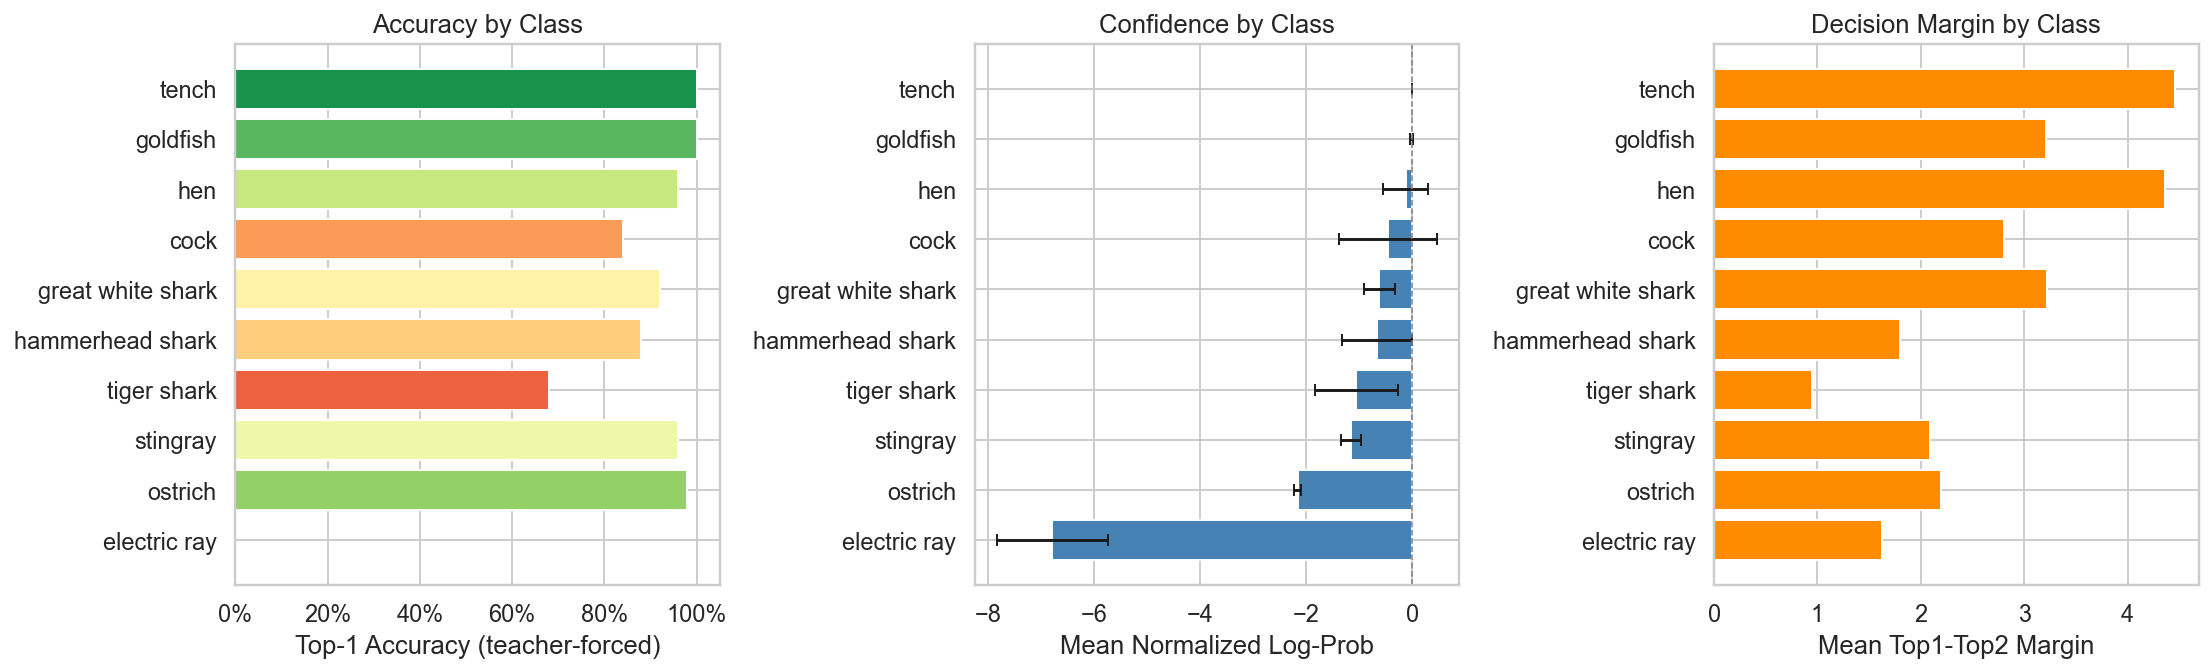

,mean_lp,std_lp,mean_rank,top1_acc,mean_margin
ground_truth_label,,,,,
electric ray,-6.794,1.050,6.84,0.00,1.624
ostrich,-2.165,0.066,1.02,0.98,2.196
stingray,-1.163,0.192,1.04,0.96,2.087
tiger shark,-1.064,0.784,1.58,0.68,0.951
hammerhead shark,-0.673,0.659,1.22,0.88,1.794
great white shark,-0.625,0.296,1.10,0.92,3.218
cock,-0.461,0.926,1.16,0.84,2.806
hen,-0.128,0.422,1.04,0.96,4.358
goldfish,-0.020,0.025,1.00,1.00,3.211


In [3]:
# Per-class stats
cls = gt.groupby("ground_truth_label").agg(
    mean_lp=("log_prob_norm", "mean"),
    std_lp=("log_prob_norm", "std"),
    mean_rank=("candidate_rank", "mean"),
).join(
    top1.assign(correct=top1["candidate_label"] == top1["ground_truth_label"])
    .groupby("ground_truth_label")["correct"].mean()
    .rename("top1_acc")
)

# Add mean margin per class
margin_by_img = margins.rename("margin").reset_index()
margin_by_img = margin_by_img.merge(images[["image_idx", "ground_truth_label"]], on="image_idx")
cls = cls.join(margin_by_img.groupby("ground_truth_label")["margin"].mean().rename("mean_margin"))
cls = cls.sort_values("mean_lp")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Top-1 accuracy bar
order = cls.index
colors = sns.color_palette("RdYlGn", n_colors=len(order))
rank_colors = [colors[i] for i in np.argsort(np.argsort(cls["top1_acc"].values))]
axes[0].barh(order, cls["top1_acc"], color=rank_colors)
axes[0].set_xlim(0, 1.05)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel("Top-1 Accuracy (teacher-forced)")
axes[0].set_title("Accuracy by Class")

# Mean log-prob bar with error bars
axes[1].barh(order, cls["mean_lp"], xerr=cls["std_lp"], color="steelblue", capsize=3)
axes[1].set_xlabel("Mean Normalized Log-Prob")
axes[1].set_title("Confidence by Class")
axes[1].axvline(0, color="grey", ls="--", lw=0.8)

# Mean margin
axes[2].barh(order, cls["mean_margin"], color="darkorange")
axes[2].set_xlabel("Mean Top1-Top2 Margin")
axes[2].set_title("Decision Margin by Class")

plt.tight_layout()
plt.show()
cls.round(3)

## 3. Confusion matrix (teacher-forced top-1)

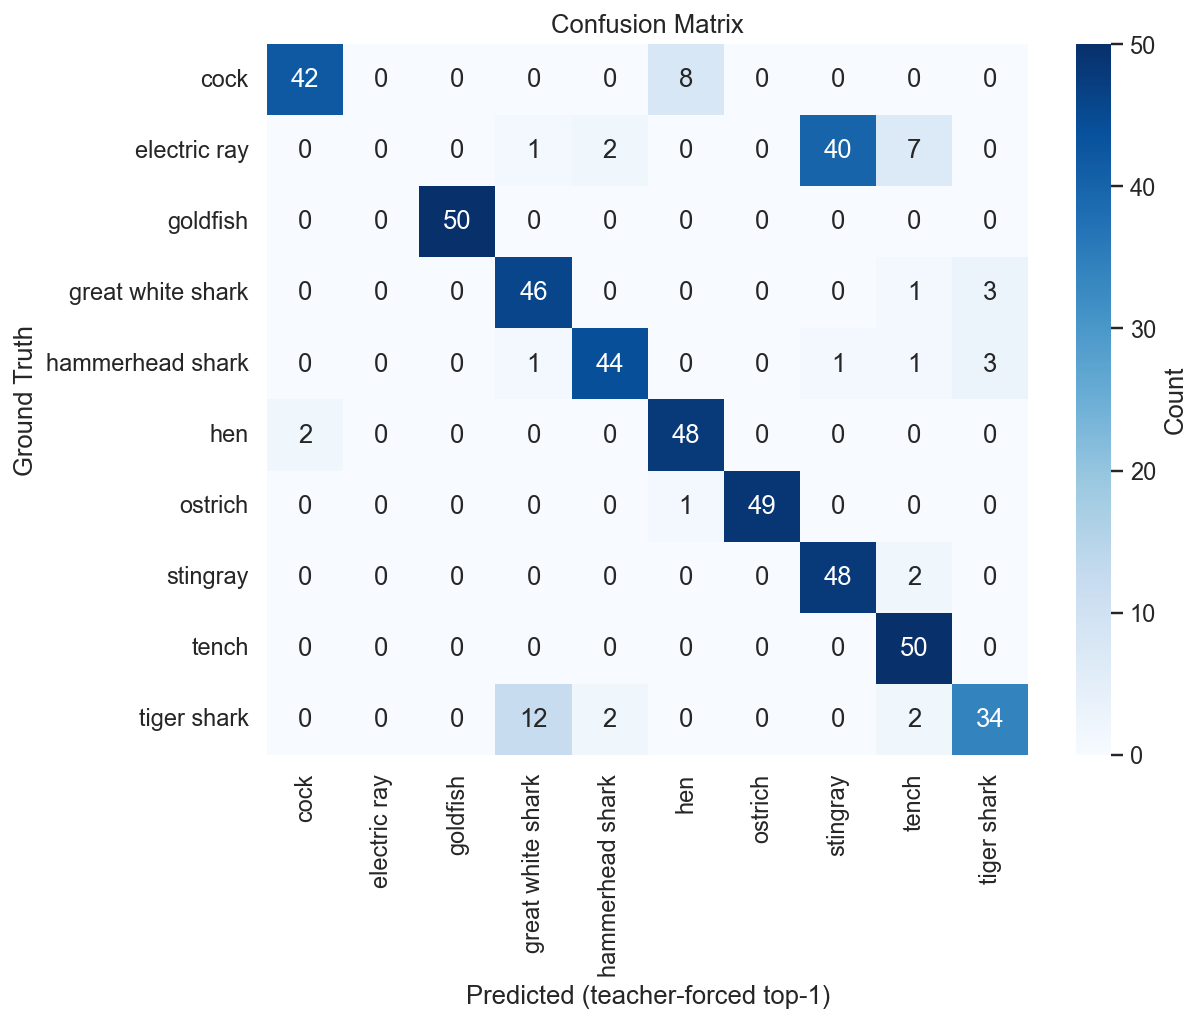

In [4]:
from sklearn.metrics import confusion_matrix

# top1 already has ground_truth_label from the sc merge
labels_order = sorted(images["ground_truth_label"].unique())
cm = confusion_matrix(top1["ground_truth_label"], top1["candidate_label"], labels=labels_order)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=ax,
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted (teacher-forced top-1)")
ax.set_ylabel("Ground Truth")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Log-prob distributions per class

/var/folders/nn/j1m3vy916r1_3cc86d7ppdk80000gn/T/ipykernel_44737/3082530382.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gt, y="ground_truth_label", x="log_prob_norm",


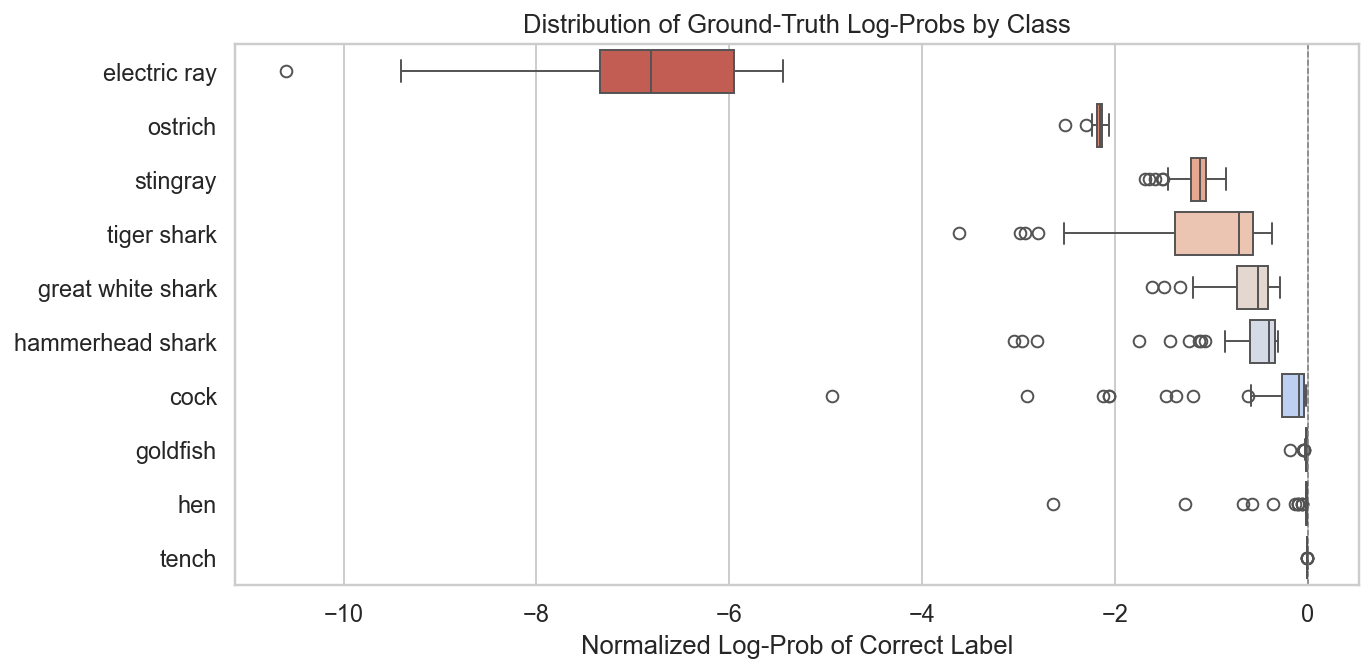

In [5]:
# Box plot of ground-truth log-probs per class
order_by_median = (
    gt.groupby("ground_truth_label")["log_prob_norm"]
    .median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=gt, y="ground_truth_label", x="log_prob_norm",
            order=order_by_median, palette="coolwarm_r", ax=ax)
ax.axvline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Normalized Log-Prob of Correct Label")
ax.set_ylabel("")
ax.set_title("Distribution of Ground-Truth Log-Probs by Class")
plt.tight_layout()
plt.show()

## 5. Margin analysis — decision boundary tightness

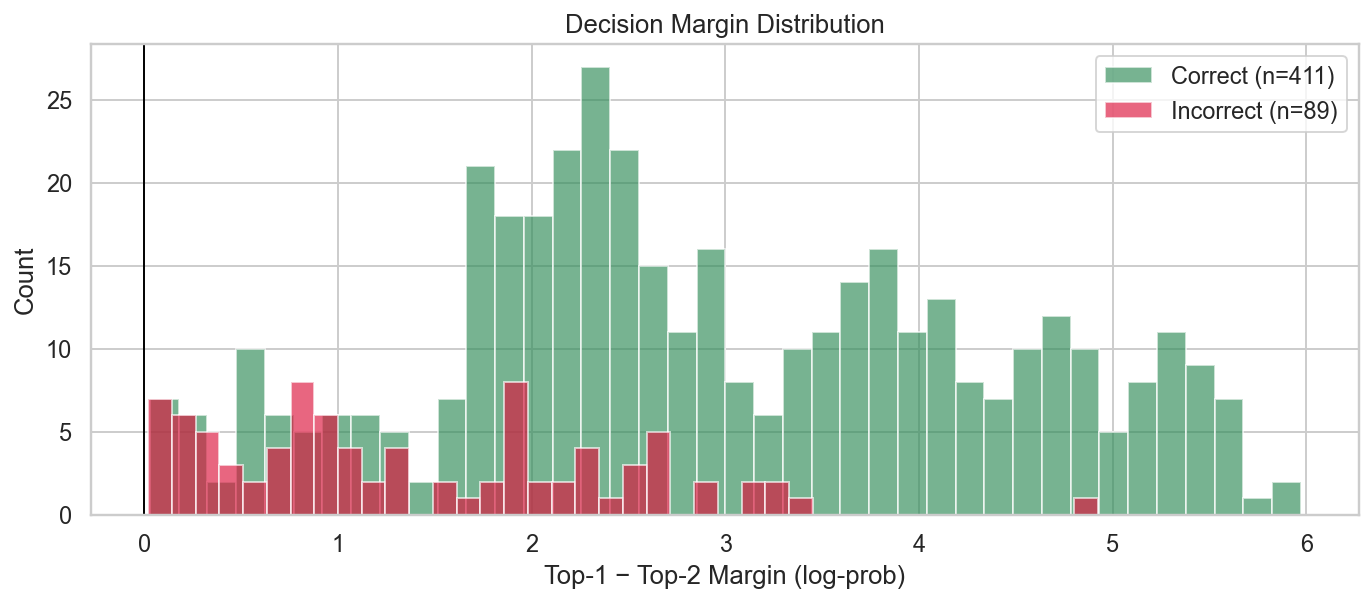

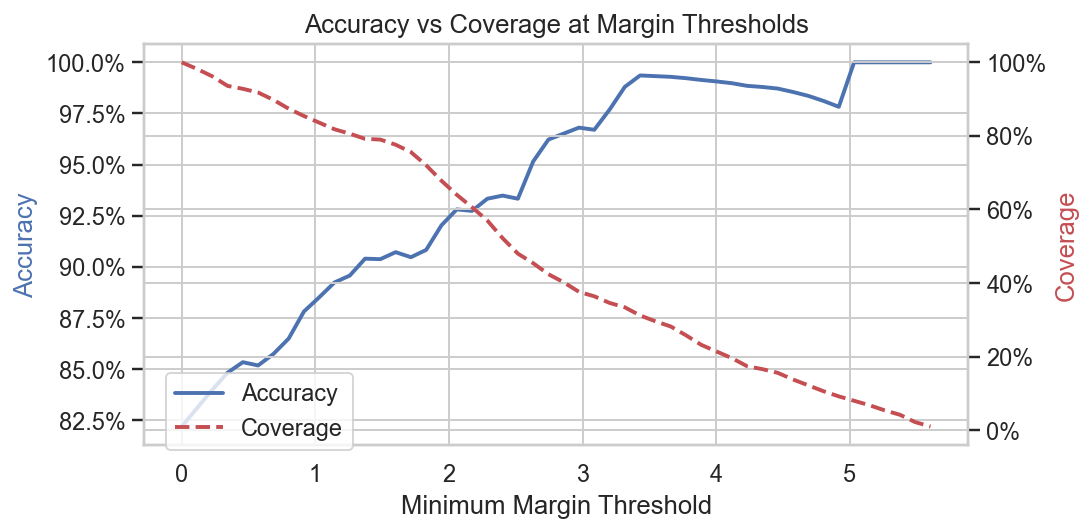

In [6]:
# Margin histogram: correct vs incorrect predictions
margin_df = margins.reset_index().rename(columns={"log_prob_norm": "margin"})
margin_df = margin_df.merge(images[["image_idx", "ground_truth_label"]], on="image_idx")
margin_df = margin_df.merge(
    top1[["image_idx", "candidate_label"]].rename(columns={"candidate_label": "pred_label"}),
    on="image_idx",
)
margin_df["correct"] = margin_df["pred_label"] == margin_df["ground_truth_label"]

fig, ax = plt.subplots(figsize=(10, 4.5))
for label, color in [("Correct", "seagreen"), ("Incorrect", "crimson")]:
    subset = margin_df[margin_df["correct"] == (label == "Correct")]
    ax.hist(subset["margin"], bins=40, alpha=0.65, label=f"{label} (n={len(subset)})", color=color)
ax.axvline(0, color="black", ls="-", lw=1)
ax.set_xlabel("Top-1 − Top-2 Margin (log-prob)")
ax.set_ylabel("Count")
ax.set_title("Decision Margin Distribution")
ax.legend()
plt.tight_layout()
plt.show()

# Margin vs accuracy: what fraction are correct at different margin thresholds?
thresholds = np.linspace(0, margin_df["margin"].quantile(0.99), 50)
acc_at_thresh = [margin_df[margin_df["margin"] >= t]["correct"].mean() for t in thresholds]
cov_at_thresh = [(margin_df["margin"] >= t).mean() for t in thresholds]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(thresholds, acc_at_thresh, "b-", lw=2, label="Accuracy")
ax1.set_xlabel("Minimum Margin Threshold")
ax1.set_ylabel("Accuracy", color="b")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2 = ax1.twinx()
ax2.plot(thresholds, cov_at_thresh, "r--", lw=2, label="Coverage")
ax2.set_ylabel("Coverage", color="r")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_title("Accuracy vs Coverage at Margin Thresholds")
fig.legend(loc="lower left", bbox_to_anchor=(0.15, 0.15))
plt.tight_layout()
plt.show()

## 6. Full score heatmap — mean log-prob per (ground truth, candidate) pair

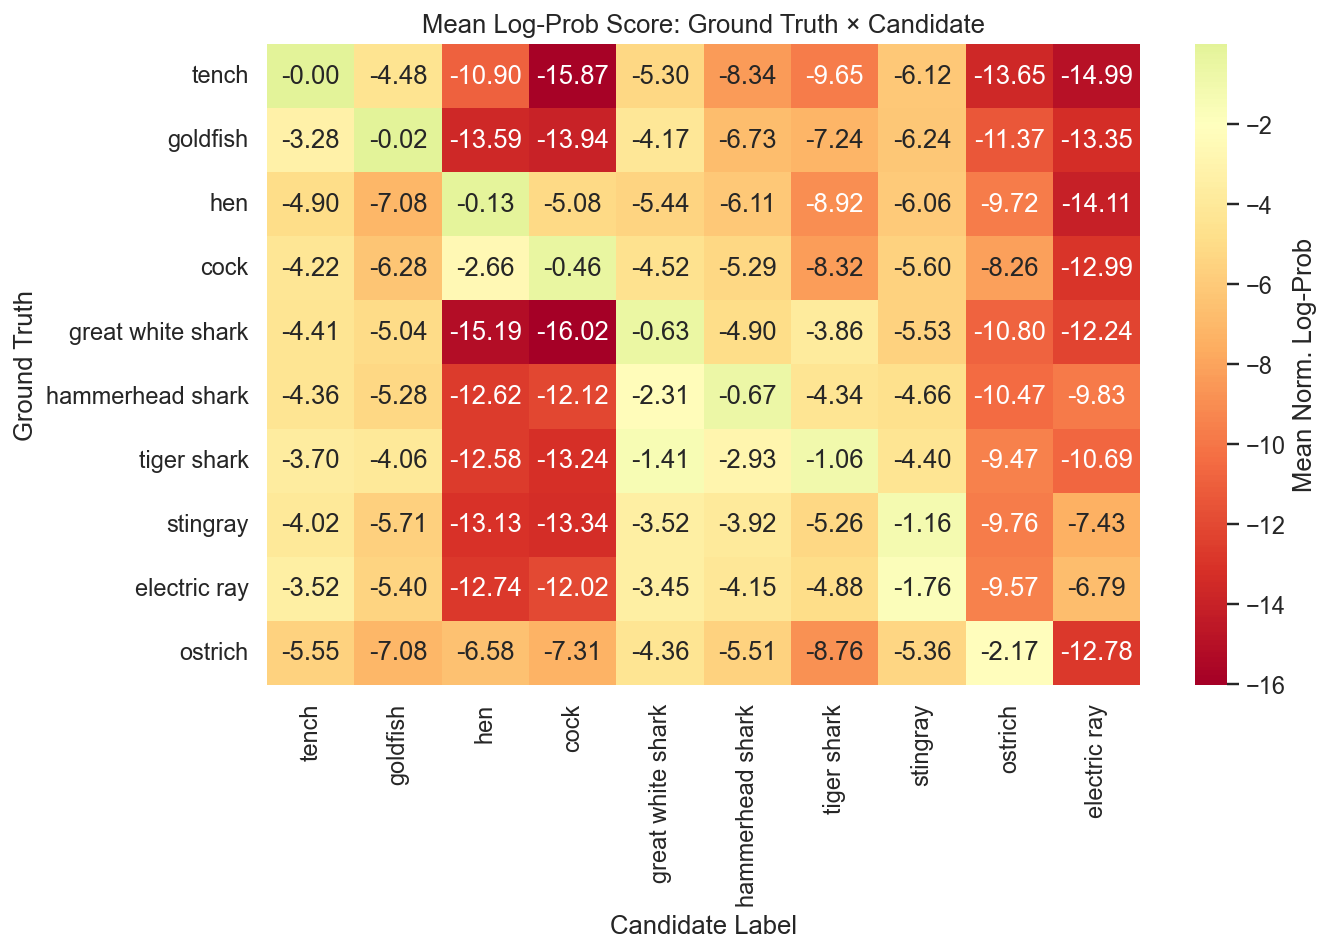

In [7]:
# Mean log-prob heatmap: for each GT class, what's the average score of each candidate?
pivot = sc.groupby(["ground_truth_label", "candidate_label"])["log_prob_norm"].mean().unstack()
# Order rows/cols by overall score
row_order = pivot.max(axis=1).sort_values(ascending=False).index
col_order = pivot.max(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=-2, ax=ax,
            cbar_kws={"label": "Mean Norm. Log-Prob"})
ax.set_xlabel("Candidate Label")
ax.set_ylabel("Ground Truth")
ax.set_title("Mean Log-Prob Score: Ground Truth × Candidate")
plt.tight_layout()
plt.show()

## 7. Rank distribution of ground-truth label

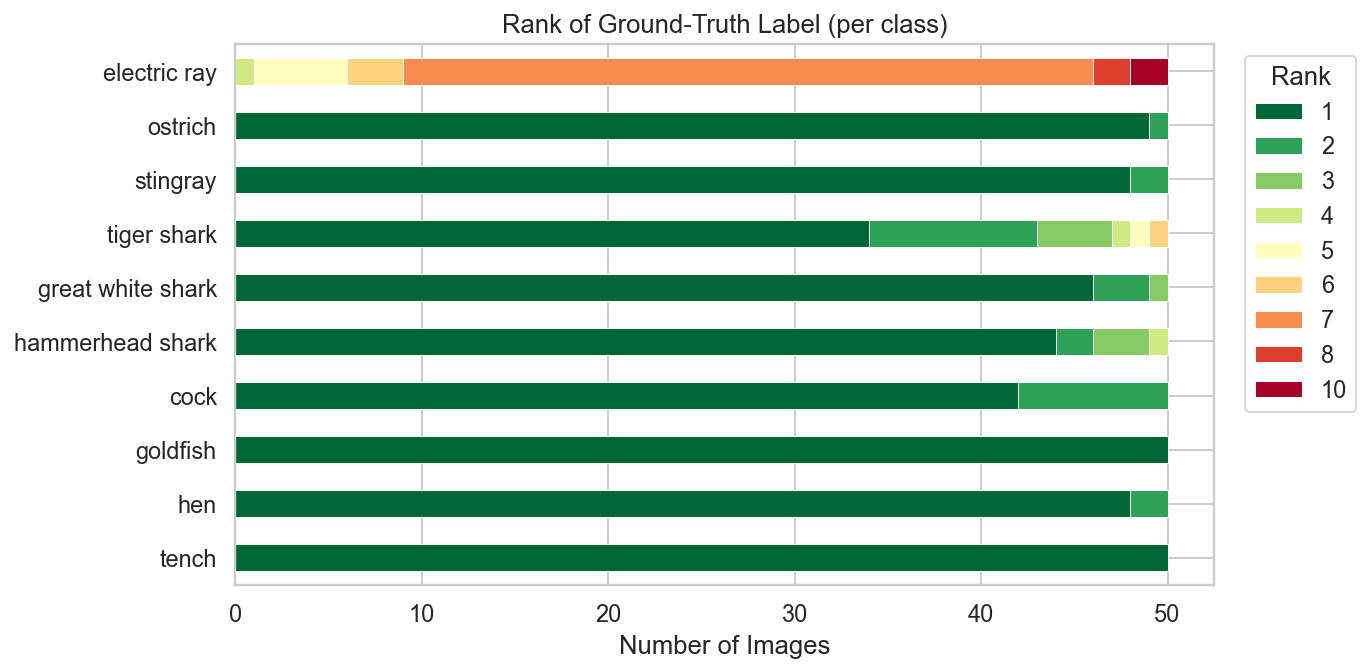

In [8]:
# Stacked bar: where does the GT label rank for each class?
rank_counts = gt.groupby(["ground_truth_label", "candidate_rank"]).size().unstack(fill_value=0)
rank_counts = rank_counts.loc[order_by_median[::-1]]  # easiest on top

fig, ax = plt.subplots(figsize=(10, 5))
rank_counts.plot.barh(stacked=True, ax=ax, cmap="RdYlGn_r", edgecolor="white", lw=0.5)
ax.set_xlabel("Number of Images")
ax.set_ylabel("")
ax.set_title("Rank of Ground-Truth Label (per class)")
ax.legend(title="Rank", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()
plt.show()

## 8. Free generation vs teacher-forced agreement

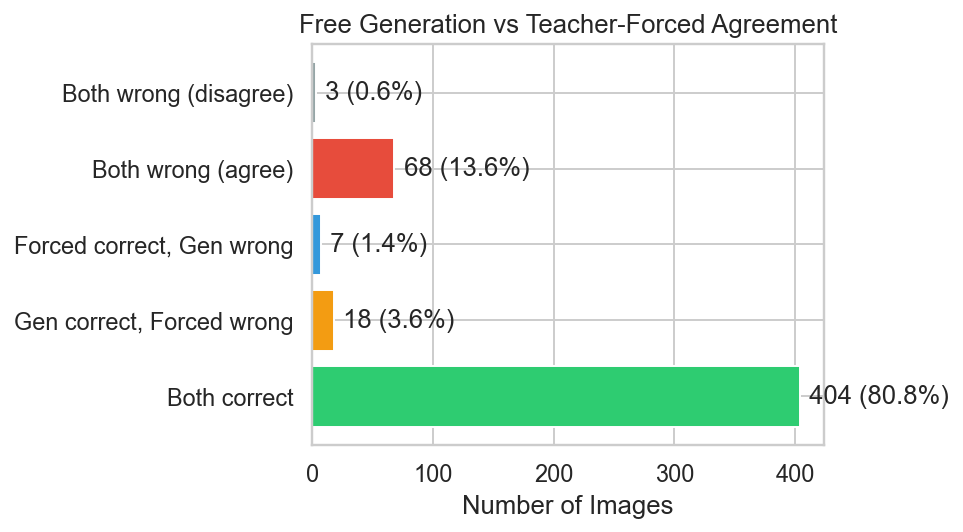

In [9]:
# Compare free generation vs teacher-forced top-1
comp = images[["image_idx", "ground_truth_label", "generated_text"]].merge(
    top1[["image_idx", "candidate_label"]].rename(columns={"candidate_label": "forced_pred"}),
    on="image_idx",
)
comp["gen_correct"] = comp["generated_text"].str.lower() == comp["ground_truth_label"].str.lower()
comp["forced_correct"] = comp["forced_pred"] == comp["ground_truth_label"]
comp["agree"] = comp["generated_text"].str.lower() == comp["forced_pred"].str.lower()

agree_stats = pd.DataFrame({
    "Category": ["Both correct", "Gen correct, Forced wrong", "Forced correct, Gen wrong",
                  "Both wrong (agree)", "Both wrong (disagree)"],
    "Count": [
        ((comp["gen_correct"]) & (comp["forced_correct"])).sum(),
        ((comp["gen_correct"]) & (~comp["forced_correct"])).sum(),
        ((~comp["gen_correct"]) & (comp["forced_correct"])).sum(),
        ((~comp["gen_correct"]) & (~comp["forced_correct"]) & (comp["agree"])).sum(),
        ((~comp["gen_correct"]) & (~comp["forced_correct"]) & (~comp["agree"])).sum(),
    ],
})
agree_stats["Pct"] = (agree_stats["Count"] / len(comp) * 100).round(1).astype(str) + "%"

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71", "#f39c12", "#3498db", "#e74c3c", "#95a5a6"]
ax.barh(agree_stats["Category"], agree_stats["Count"], color=colors)
for i, (c, pct) in enumerate(zip(agree_stats["Count"], agree_stats["Pct"])):
    ax.text(c + 2, i, f" {c} ({pct})", va="center")
ax.set_xlabel("Number of Images")
ax.set_title("Free Generation vs Teacher-Forced Agreement")
plt.tight_layout()
plt.show()

## 9. Electric ray deep-dive (worst class)

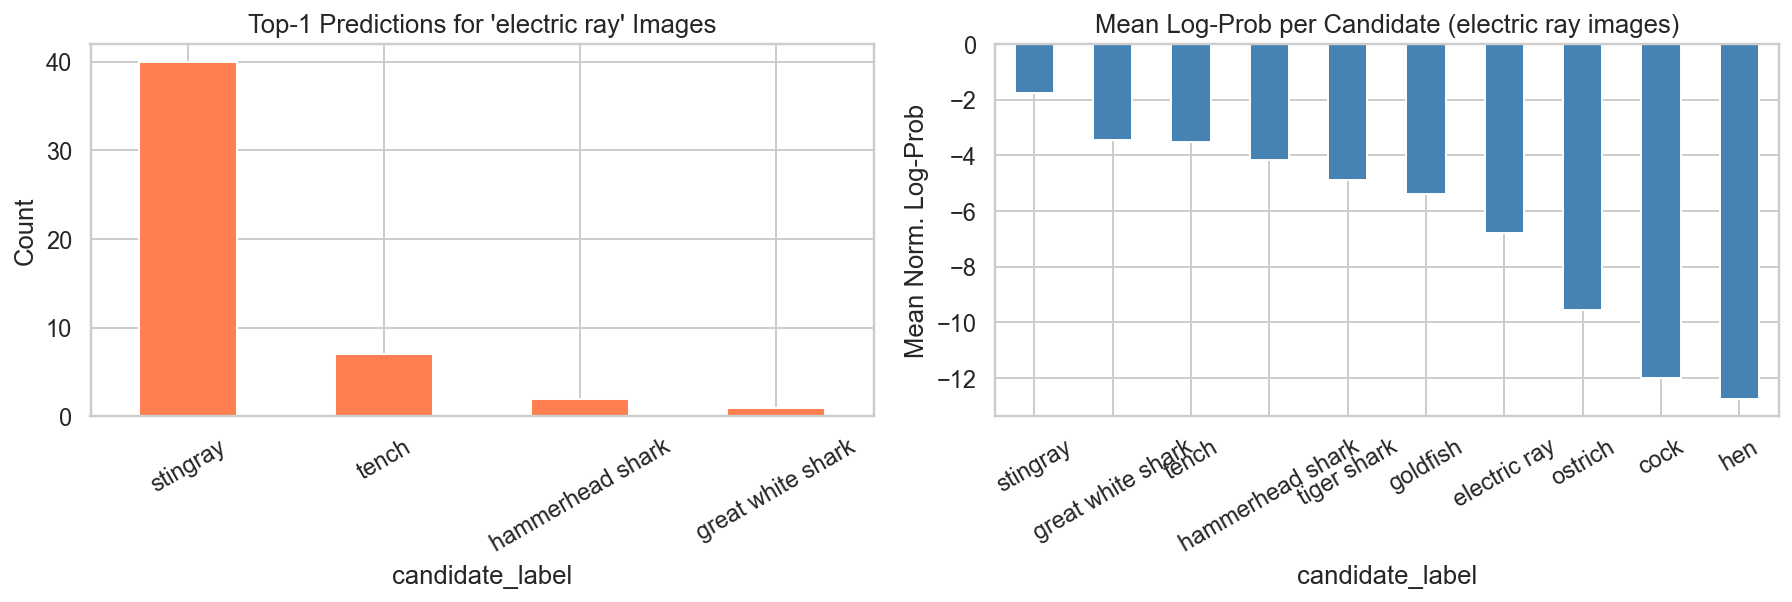

Electric ray top-1 predictions:
candidate_label
stingray             40
tench                 7
hammerhead shark      2
great white shark     1

Free generation answers for electric ray:
generated_text
stingray             33
electric ray         13
tench                 3
great white shark     1


In [10]:
# What does the model predict for electric ray images?
er_imgs = images[images["ground_truth_label"] == "electric ray"]["image_idx"]
er_scores = sc[sc["image_idx"].isin(er_imgs)]

# Distribution of top-1 predictions for electric ray
er_top1 = er_scores[er_scores["candidate_rank"] == 1]
pred_dist = er_top1["candidate_label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: what does the model predict instead?
pred_dist.plot.bar(ax=axes[0], color="coral")
axes[0].set_title("Top-1 Predictions for 'electric ray' Images")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Right: score distribution for all candidates on electric ray images
er_mean = er_scores.groupby("candidate_label")["log_prob_norm"].mean().sort_values(ascending=False)
er_mean.plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("Mean Log-Prob per Candidate (electric ray images)")
axes[1].set_ylabel("Mean Norm. Log-Prob")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(0, color="grey", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

print(f"Electric ray top-1 predictions:\n{pred_dist.to_string()}")
print(f"\nFree generation answers for electric ray:")
er_gen = images[images["ground_truth_label"] == "electric ray"]["generated_text"].value_counts()
print(er_gen.to_string())

## 10. Semantic cluster analysis — pairwise confusion rates

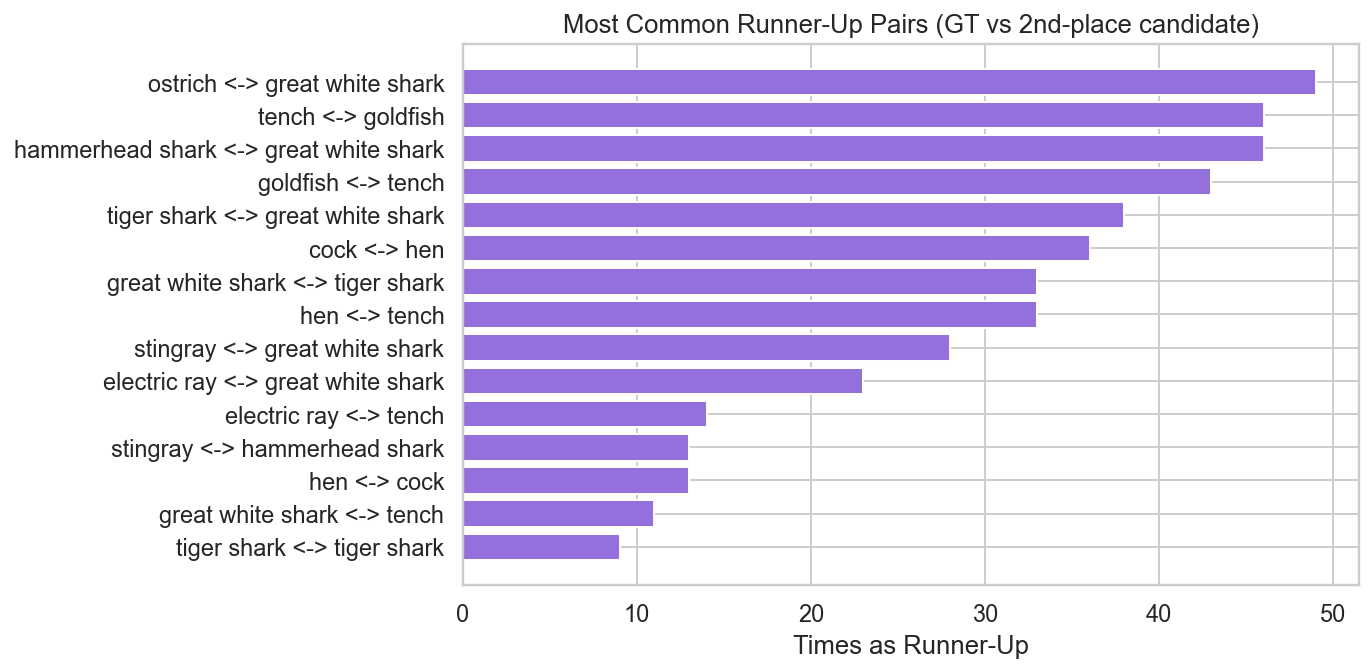

In [11]:
# For each GT class, which candidate gets the 2nd highest score?
runner_up = sc[sc["candidate_rank"] == 2].copy()
confusion_pairs = (
    runner_up.groupby(["ground_truth_label", "candidate_label"])
    .size().reset_index(name="count")
    .sort_values("count", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
top_pairs = confusion_pairs.head(15)
labels = [f"{r.ground_truth_label} <-> {r.candidate_label}" for _, r in top_pairs.iterrows()]
ax.barh(labels[::-1], top_pairs["count"].values[::-1], color="mediumpurple")
ax.set_xlabel("Times as Runner-Up")
ax.set_title("Most Common Runner-Up Pairs (GT vs 2nd-place candidate)")
plt.tight_layout()
plt.show()